## **Exercise 1**

In [33]:
import pandas as pd

In [34]:
df = pd.read_csv('Titanic-Dataset.csv')

In [35]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [37]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.dropna(subset=['Embarked'])
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

In [38]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [39]:
df.duplicated().sum()

np.int64(0)

### Data Overview

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        889 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [41]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Categorical Feature Distribution

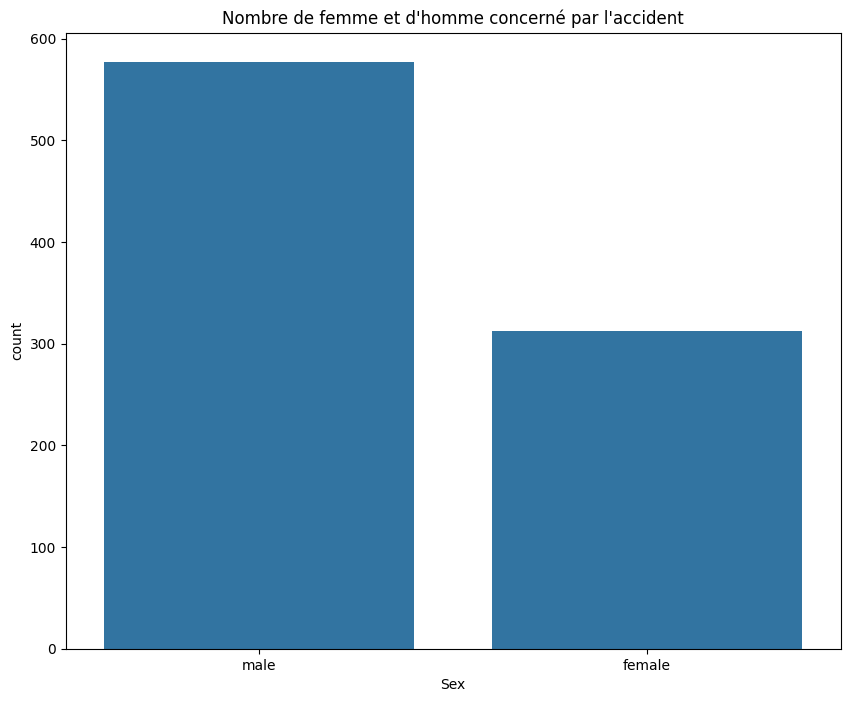

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.countplot(x='Sex', data=df)
plt.title('Nombre de femme et d\'homme concerné par l\'accident');



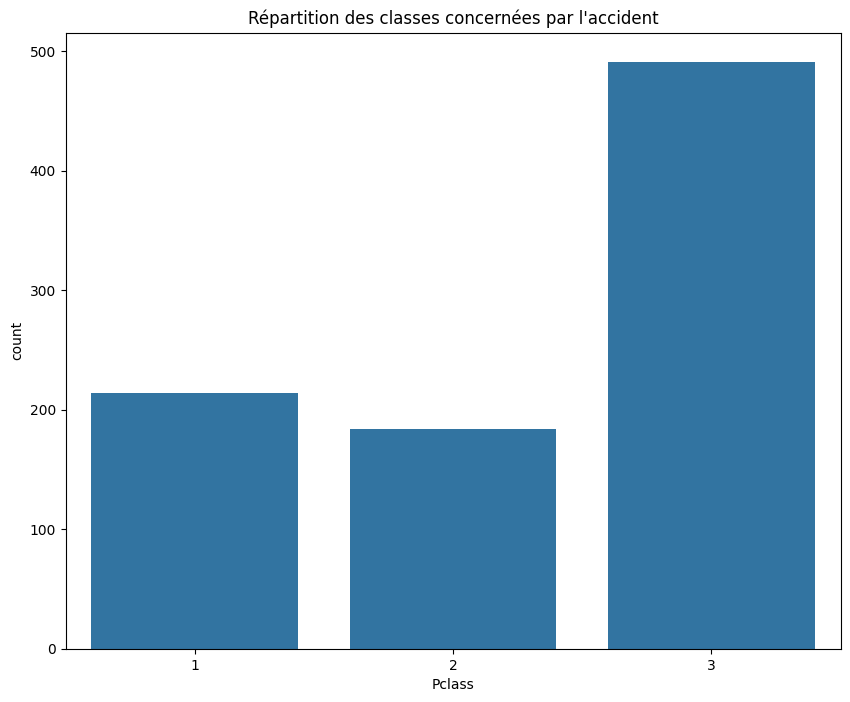

In [43]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Pclass', data=df)
plt.title('Répartition des classes concernées par l\'accident');


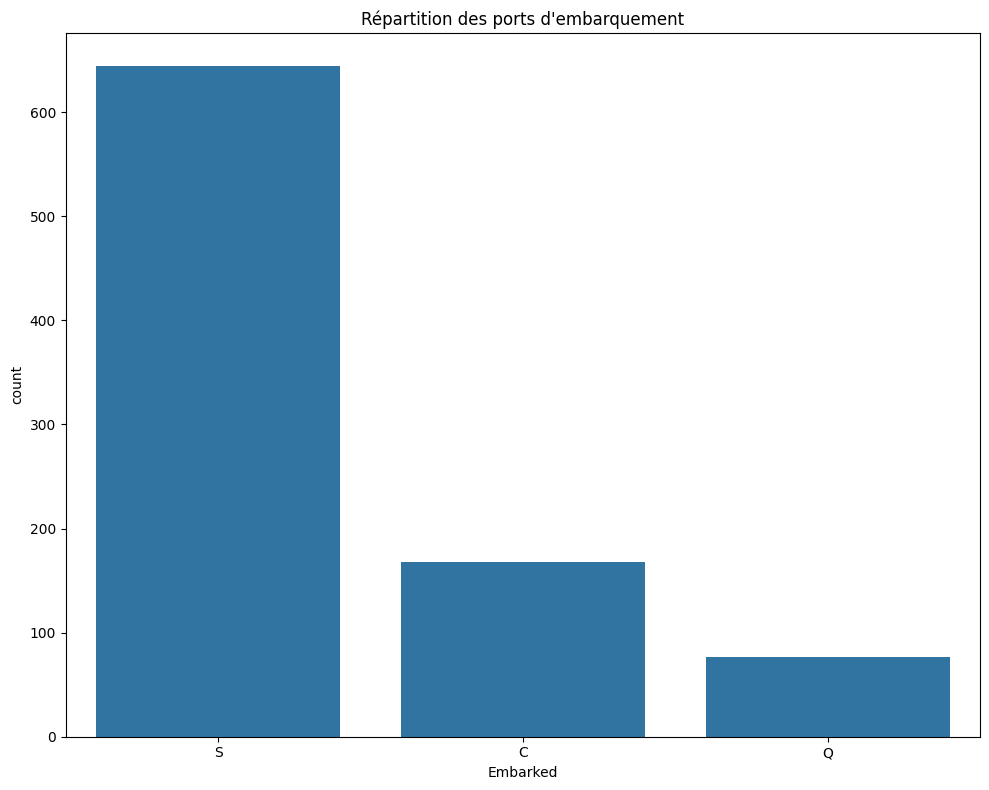

In [44]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Embarked', data=df)
plt.title('Répartition des ports d\'embarquement');

plt.tight_layout()
plt.show()

## **Exercice 2**

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [46]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [47]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [48]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [49]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [50]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [105]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42,class_weight='balanced')
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

In [106]:
y_dt_pred = dt.predict(X_test)

In [107]:
acc_dt = accuracy_score(y_test, y_dt_pred)
prec_dt = precision_score(y_test, y_dt_pred)
rec_dt = recall_score(y_test, y_dt_pred)
f1_dt = f1_score(y_test, y_dt_pred)

In [108]:
print(f"Accuracy: {acc_dt}")
print(f"Precision: {prec_dt}")
print(f"Recall: {rec_dt}")
print(f"F1-Score: {f1_dt}")

Accuracy: 0.7584269662921348
Precision: 0.6354166666666666
Recall: 0.8840579710144928
F1-Score: 0.7393939393939394


## **Exercice 3**

In [65]:
from sklearn.model_selection import GridSearchCV

In [75]:
new_dt = DecisionTreeClassifier()

In [94]:
param_grid = {
    "max_depth" : [3,4,5,6,7,8,9,10],
    "class_weight" : ["balanced","balanced_subsample"],
    "criterion" : ["gini","entropy"],
    "random_state" : [42],
    "min_samples_split" : [2,3,4],
    "min_samples_leaf" : [1,2,3],
}

In [95]:
grid_model = GridSearchCV(new_dt, param_grid=param_grid, cv=5)

In [96]:
grid_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
720 fits failed out of a total of 1440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
720 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4], 'random_state': [42]})

In [85]:
best_model = grid_model.best_estimator_

In [86]:
print(best_model)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=3,
                       random_state=42)


On voit alors les meuilleures paramètres du modèle

In [97]:
best_dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=3, random_state=42)

In [98]:
best_dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=3,
                       random_state=42)

In [99]:
best_y_dt = best_dt.predict(X_test)

In [100]:
best_dt_acc = accuracy_score(y_test, best_y_dt)
best_dt_prec = precision_score(y_test, best_y_dt)
best_dt_rec = recall_score(y_test, best_y_dt)
best_dt_f1 = f1_score(y_test, best_y_dt)

In [101]:
print(f"Accuracy: {best_dt_acc}")
print(f"Precision: {best_dt_prec}")
print(f"Recall: {best_dt_rec}")
print(f"F1-Score: {best_dt_f1}")

Accuracy: 0.7471910112359551
Precision: 0.6363636363636364
Recall: 0.8115942028985508
F1-Score: 0.7133757961783439


Après optimisation des hyperparamètres par GridSearchCV, le meilleur arbre obtenu utilise max_depth=5, min_samples_leaf=3 et class_weight='balanced'. Cependant, le modèle de base semble être plus performant avec les paramètres par défaut

## **Exercice 4**

In [102]:
from sklearn.neighbors import KNeighborsClassifier

In [115]:
knn = KNeighborsClassifier(n_neighbors=5,n_jobs=1)

In [116]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_jobs=1)

In [117]:
knn_y_pred = knn.predict(X_test)

In [118]:
acc_knn = accuracy_score(y_test, knn_y_pred)
prec_knn = precision_score(y_test, knn_y_pred)
rec_knn = recall_score(y_test, knn_y_pred)
f1_knn = f1_score(y_test, knn_y_pred)

In [119]:
print(f"Accuracy: {acc_knn}")
print(f"Precision: {prec_knn}")
print(f"Recall: {rec_knn}")
print(f"F1-Score: {f1_knn}")

Accuracy: 0.7865168539325843
Precision: 0.7183098591549296
Recall: 0.7391304347826086
F1-Score: 0.7285714285714285


## **Exercice 5**

In [120]:
param_grid_knn = {
    "n_neighbors" : [3,4,5,6,7,8,9,10],
    "weights" : ["uniform","distance"],
    "algorithm" : ["auto","ball_tree","kd_tree","brute"],
}

In [121]:
grid_search_knn = GridSearchCV(knn, param_grid=param_grid_knn, cv=5)

In [122]:
grid_search_knn.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_jobs=1),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10],
                         'weights': ['uniform', 'distance']})

In [123]:
print(grid_search_knn.best_params_)

{'algorithm': 'ball_tree', 'n_neighbors': 4, 'weights': 'uniform'}


In [124]:
best_knn = KNeighborsClassifier(n_neighbors=4, weights='uniform', algorithm='ball_tree', n_jobs=1)

In [125]:
best_knn.fit(X_train,y_train)

KNeighborsClassifier(algorithm='ball_tree', n_jobs=1, n_neighbors=4)

In [126]:
best_y_knn = best_knn.predict(X_test)

In [127]:
acc_best_knn = accuracy_score(y_test, best_y_knn)
prec_best_knn = precision_score(y_test, best_y_knn)
rec_best_knn = recall_score(y_test, best_y_knn)
f1_best_knn = f1_score(y_test, best_y_knn)

In [128]:
print(f"Accuracy: {acc_best_knn}")
print(f"Precision: {prec_best_knn}")
print(f"Recall: {rec_best_knn}")
print(f"F1-Score: {f1_best_knn}")


Accuracy: 0.7752808988764045
Precision: 0.7101449275362319
Recall: 0.7101449275362319
F1-Score: 0.7101449275362319


## **Exercice 6**

In [129]:
from sklearn.neural_network import MLPClassifier

# Initialize the MLPClassifier with default parameters (or reasonable choices)
mlp = MLPClassifier(random_state=42, max_iter=500)

# Train the model
mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(max_iter=500, random_state=42)

In [130]:
# Make predictions on the test set
mlp_y_pred = mlp.predict(X_test)

# Calculate evaluation metrics
acc_mlp = accuracy_score(y_test, mlp_y_pred)
prec_mlp = precision_score(y_test, mlp_y_pred)
rec_mlp = recall_score(y_test, mlp_y_pred)
f1_mlp = f1_score(y_test, mlp_y_pred)

In [131]:
# Print the evaluation metrics
print(f"Accuracy (MLP): {acc_mlp}")
print(f"Precision (MLP): {prec_mlp}")
print(f"Recall (MLP): {rec_mlp}")
print(f"F1-Score (MLP): {f1_mlp}")

Accuracy (MLP): 0.797752808988764
Precision (MLP): 0.746268656716418
Recall (MLP): 0.7246376811594203
F1-Score (MLP): 0.7352941176470589
